In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression, ElasticNet, Lasso, Ridge
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.feature_selection import SelectKBest, f_classif, f_regression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, roc_curve, auc

from sklearn.preprocessing import KBinsDiscretizer

In [2]:
df=pd.read_csv('heart_failure_clinical_records_dataset.csv')

# Lectura de Datos

In [4]:
df.head()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1


In [5]:
df.shape

(299, 13)

# Diccionario de datos

**El objetivo** de este proyecto final es que mediante el dataset de Heart Failure podamos realizar predicciones y estimaciones sobre qué factores pueden estar relacionados a la muerte de personas con insuficiencia cardíaca. La data para usar es la siguiente:

- Age: age
- Anemia: Decrease of red blood cells or hemoglobin (boolean)
- Creatinine_phosphokinase: Level of the CPK enzyme in the blood
(mcg/L)
- Diabetes: If the patient has diabetes (boolean)
- ejection_fraction: Percentage of blood leaving the heart at each
contraction (percentage)
- high_blood_pressure: If the patient has hypertension (boolean)
- platelets: Platelets in the blood (kiloplatelets/mL)
- serum_creatinine: Level of serum creatinine in the blood (mg/dL)
- serum_sofium: Level of serum sodium in the blood (mEq/L)
- sex: Woman or man (binary)
- smoking: If the patient smokes or not (boolean)
- time: Follow-up period (days)
- DEATH_EVENT: If the patient deceased during the follow-up period
(boolean)

# Exploración / Inspección / Limpieza

In [9]:
df.isna().sum(),df.isna().sum()/len(df)

(age                         0
 anaemia                     0
 creatinine_phosphokinase    0
 diabetes                    0
 ejection_fraction           0
 high_blood_pressure         0
 platelets                   0
 serum_creatinine            0
 serum_sodium                0
 sex                         0
 smoking                     0
 time                        0
 DEATH_EVENT                 0
 dtype: int64,
 age                         0.0
 anaemia                     0.0
 creatinine_phosphokinase    0.0
 diabetes                    0.0
 ejection_fraction           0.0
 high_blood_pressure         0.0
 platelets                   0.0
 serum_creatinine            0.0
 serum_sodium                0.0
 sex                         0.0
 smoking                     0.0
 time                        0.0
 DEATH_EVENT                 0.0
 dtype: float64)

In [10]:
df['DEATH_EVENT'].value_counts() , df['DEATH_EVENT'].value_counts(1)*100

(DEATH_EVENT
 0    203
 1     96
 Name: count, dtype: int64,
 DEATH_EVENT
 0    67.892977
 1    32.107023
 Name: proportion, dtype: float64)

In [11]:
varc=['age', 'anaemia', 'creatinine_phosphokinase', 'diabetes',
       'ejection_fraction', 'high_blood_pressure', 'platelets',
       'serum_creatinine', 'serum_sodium', 'sex', 'smoking', 'time',
       'log_creatinine_phosphokinase', 'is_old', 'low_ef',
       'high_creatinine', 'low_platelets', 'interaction_age_ef',
       'hypertension_diabetes', 'risk_score', 'platelets_to_creatinine_ratio']
target=['DEATH_EVENT']

In [12]:
for col in df.columns.tolist()+[target]:
    display(df[col].value_counts(normalize=True).reset_index())

,age,proportion
0,60.000,0.110368
1,50.000,0.090301
2,65.000,0.086957
3,70.000,0.083612
4,45.000,0.063545
5,55.000,0.056856
6,75.000,0.036789
7,53.000,0.033445
8,58.000,0.033445
9,63.000,0.026756


,anaemia,proportion
0,0,0.568562
1,1,0.431438


,creatinine_phosphokinase,proportion
0,582,0.157191
1,66,0.013378
2,129,0.013378
3,231,0.010033
4,69,0.010033
...,...,...
203,748,0.003344
204,1876,0.003344
205,936,0.003344
206,292,0.003344


,diabetes,proportion
0,0,0.58194
1,1,0.41806


,ejection_fraction,proportion
0,35,0.163880
1,38,0.133779
2,40,0.123746
3,25,0.120401
4,30,0.113712
5,60,0.103679
6,50,0.070234
7,45,0.066890
8,20,0.060201
9,55,0.010033


...

,sex,proportion
0,1,0.648829
1,0,0.351171


,smoking,proportion
0,0,0.67893
1,1,0.32107


,time,proportion
0,250,0.023411
1,187,0.023411
2,10,0.020067
3,186,0.020067
4,107,0.020067
...,...,...
143,97,0.003344
144,96,0.003344
145,86,0.003344
146,77,0.003344


,DEATH_EVENT,proportion
0,0,0.67893
1,1,0.32107


,DEATH_EVENT,proportion
0,0,0.67893
1,1,0.32107


Se observa que los datos son bastantes limpios, dado que no contamos con valores vacíos, pero conforme vayamos avanzando buscaremos si hay alguna modificación adicional que pueda requerir. De igual forma se observa que mo hay valores atípicos que sean necesario quitar.

# Ingeniería de variables

In [15]:
df['log_creatinine_phosphokinase']=np.log(df['creatinine_phosphokinase'])

df['is_old']=(df['age']>60)*1

df['low_ef']=(df['ejection_fraction']<35)*1

df['high_creatinine']=(df['serum_creatinine']>1.2)*1

df['low_platelets']=(df['platelets']<150)*1

df['interaction_age_ef']=df['age']*df['ejection_fraction']

df['hypertension_diabetes']=((df['high_blood_pressure'] ==1)&(df['diabetes']==1))*1

df['risk_score']=(
    df['is_old'].astype(int)
    + df['low_ef'].astype(int)
    + df['high_creatinine'].astype(int)
    + df['anaemia'].astype(int)
    + df['smoking'].astype(int)
    + df['diabetes'].astype(int)
    + df['high_blood_pressure'].astype(int)
)

df['platelets_to_creatinine_ratio']=df['platelets']/(df['serum_creatinine']+0.1)

In [16]:
df.dtypes

age                              float64
anaemia                            int64
creatinine_phosphokinase           int64
diabetes                           int64
ejection_fraction                  int64
high_blood_pressure                int64
platelets                        float64
serum_creatinine                 float64
serum_sodium                       int64
sex                                int64
smoking                            int64
time                               int64
DEATH_EVENT                        int64
log_creatinine_phosphokinase     float64
is_old                             int64
low_ef                             int64
high_creatinine                    int64
low_platelets                      int64
interaction_age_ef               float64
hypertension_diabetes              int64
risk_score                         int64
platelets_to_creatinine_ratio    float64
dtype: object

# Análisis Exploratorio

In [18]:
df.columns

Index(['age', 'anaemia', 'creatinine_phosphokinase', 'diabetes',
       'ejection_fraction', 'high_blood_pressure', 'platelets',
       'serum_creatinine', 'serum_sodium', 'sex', 'smoking', 'time',
       'DEATH_EVENT', 'log_creatinine_phosphokinase', 'is_old', 'low_ef',
       'high_creatinine', 'low_platelets', 'interaction_age_ef',
       'hypertension_diabetes', 'risk_score', 'platelets_to_creatinine_ratio'],
      dtype='object')

In [19]:
df.describe()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,...,DEATH_EVENT,log_creatinine_phosphokinase,is_old,low_ef,high_creatinine,low_platelets,interaction_age_ef,hypertension_diabetes,risk_score,platelets_to_creatinine_ratio
count,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.00000,299.000000,299.000000,...,299.00000,299.000000,299.000000,299.000000,299.000000,299.0,299.000000,299.000000,299.000000,299.000000
mean,60.833893,0.431438,581.839465,0.418060,38.083612,0.351171,263358.029264,1.39388,136.625418,0.648829,...,0.32107,5.659896,0.458194,0.311037,0.337793,0.0,2325.206321,0.143813,2.628763,214710.837218
std,11.894809,0.496107,970.287881,0.494067,11.834841,0.478136,97804.236869,1.03451,4.412477,0.478136,...,0.46767,1.134439,0.499084,0.463694,0.473750,0.0,879.955559,0.351488,1.276784,110732.028824
min,40.000000,0.000000,23.000000,0.000000,14.000000,0.000000,25100.000000,0.50000,113.000000,0.000000,...,0.00000,3.135494,0.000000,0.000000,0.000000,0.0,630.000000,0.000000,0.000000,16593.406593
25%,51.000000,0.000000,116.500000,0.000000,30.000000,0.000000,212500.000000,0.90000,134.000000,0.000000,...,0.00000,4.757808,0.000000,0.000000,0.000000,0.0,1625.000000,0.000000,2.000000,138622.926555
50%,60.000000,0.000000,250.000000,0.000000,38.000000,0.000000,262000.000000,1.10000,137.000000,1.000000,...,0.00000,5.521461,0.000000,0.000000,0.000000,0.0,2204.000000,0.000000,3.000000,205454.545455
75%,70.000000,1.000000,582.000000,1.000000,45.000000,1.000000,303500.000000,1.40000,140.000000,1.000000,...,1.00000,6.366470,1.000000,1.000000,1.000000,0.0,2835.000000,0.000000,3.000000,271750.000000
max,95.000000,1.000000,7861.000000,1.000000,80.000000,1.000000,850000.000000,9.40000,148.000000,1.000000,...,1.00000,8.969669,1.000000,1.000000,1.000000,0.0,5100.000000,1.000000,6.000000,824444.444444


In [20]:
varc

['age',
 'anaemia',
 'creatinine_phosphokinase',
 'diabetes',
 'ejection_fraction',
 'high_blood_pressure',
 'platelets',
 'serum_creatinine',
 'serum_sodium',
 'sex',
 'smoking',
 'time',
 'log_creatinine_phosphokinase',
 'is_old',
 'low_ef',
 'high_creatinine',
 'low_platelets',
 'interaction_age_ef',
 'hypertension_diabetes',
 'risk_score',
 'platelets_to_creatinine_ratio']

# Modelos

In [22]:
X=df.drop(columns='DEATH_EVENT')
y=df['DEATH_EVENT']

In [23]:
kb = SelectKBest(k = 5, score_func=f_regression)
kb.fit(X, y)
ls_best = [x for x, y in zip(X.columns, kb.get_support()) if y]
ls_best

['serum_creatinine', 'time', 'low_ef', 'high_creatinine', 'risk_score']

In [24]:
X_train, X_test, y_train, y_test = train_test_split(X, y,random_state=150)

### Regresión logística

In [26]:
logreg = LogisticRegression()
logreg.fit(X_train, y_train)
ls_scores = cross_val_score(cv = 4, estimator=logreg, X=X_train, y=y_train,n_jobs=-1, scoring="r2")
np.mean(ls_scores), np.std(ls_scores)

/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_ite

(0.14532954006638232, 0.17258212121048203)

### Lasso

In [28]:
#sin escalar
model_lasso = Lasso(alpha=0.001)
model_lasso.fit(X_train, y_train)
ls_medias_lasso = cross_val_score(estimator=model_lasso, X=X_train, y = y_train, cv = 4, n_jobs=-1, scoring="r2")
np.mean(ls_medias_lasso), np.std(ls_medias_lasso)

(0.38004310110504663, 0.09941636793295286)

### Ridge

In [30]:
#sin escalar
model_ridge = Ridge(alpha=0.001)
model_ridge.fit(X_train, y_train)
ls_medias_ridge = cross_val_score(estimator=model_ridge, X=X_train, y = y_train, cv = 4, n_jobs=-1, scoring="r2")
np.mean(ls_medias_ridge), np.std(ls_medias_ridge)

(0.37931613329246716, 0.09903750256689411)

### ElasticNet

In [32]:
#sin escalar
model_elastic = ElasticNet(alpha=0.001)
model_elastic.fit(X_train, y_train)
ls_medias_elastic = cross_val_score(estimator=model_elastic, X=X_train, y = y_train, cv = 4, n_jobs=-1, scoring="r2")
np.mean(ls_medias_elastic), np.std(ls_medias_elastic)

/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:678: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.464e+00, tolerance: 4.921e-03
  model = cd_fast.enet_coordinate_descent(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:678: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.778e+00, tolerance: 3.664e-03
  model = cd_fast.enet_coordinate_descent(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:678: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.776e+00, toler

(0.37982395123717083, 0.09938494493478303)

### Random Forest

In [34]:
model = RandomForestClassifier(random_state=42)
scores = cross_val_score(model, X=X_train, y=y_train, cv=4, scoring="roc_auc")
scores.mean(),scores.std()

(0.9257151888730836, 0.02110405662555065)

Hiperparametrización

In [36]:
param_dict = {"n_estimators": [x for x in range(100, 1500, 100)],
              "max_features": ["auto", "sqrt", "log2"],
              "criterion": ["gini", "entropy"],
              "class_weight": ["balanced", None],
              "min_samples_split": [x for x in range(2, 50, 2)],
              "min_samples_leaf": [x/100 for x in range(5, 55, 5)]}

In [37]:
search = RandomizedSearchCV(param_distributions=param_dict, cv=4, n_jobs=-1, scoring="accuracy", estimator=model, verbose=5,n_iter=10) #,n_iter=100

In [38]:
search.fit(X_train, y_train)

Fitting 4 folds for each of 10 candidates, totalling 40 fits


/opt/anaconda3/lib/python3.12/site-packages/sklearn/model_selection/_validation.py:547: FitFailedWarning: 
12 fits failed out of a total of 40.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
11 fits failed with the following error:
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.12/site-packages/sklearn/model_selection/_validation.py", line 895, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py", line 1467, in wrapper
    estimator._validate_params()
  File "/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py", line 666, in _validate_params
    validate_parameter_constraints(
  File "/opt/anaconda3/lib/python3.12/site-pack

RandomizedSearchCV(cv=4, estimator=RandomForestClassifier(random_state=42),
                   n_jobs=-1,
                   param_distributions={'class_weight': ['balanced', None],
                                        'criterion': ['gini', 'entropy'],
                                        'max_features': ['auto', 'sqrt',
                                                         'log2'],
                                        'min_samples_leaf': [0.05, 0.1, 0.15,
                                                             0.2, 0.25, 0.3,
                                                             0.35, 0.4, 0.45,
                                                             0.5],
                                        'min_samples_split': [2, 4, 6, 8, 10,
                                                              12, 14, 16, 18,
                                                              20, 22, 24, 26,
                                                              28, 30, 32, 34,
                                                              36, 38, 40, 42,
                                                              44, 46, 48],
                                        'n_estimators': [100, 200, 300, 400,
                                                         500, 600, 700, 800,
                                                         900, 1000, 1100, 1200,
                                                         1300, 1400]},
                   scoring='accuracy', verbose=5)

In [39]:
search.best_score_

0.7946428571428572

No conviene realizar hiperparametrización

### Resultados del modelo

In [42]:
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]
print('Clasificación:')
print(classification_report(y_test, y_pred))
print(f'ROC AUC: {roc_auc_score(y_test, y_prob):.4f}')

Clasificación:
              precision    recall  f1-score   support

           0       0.82      0.90      0.86        52
           1       0.72      0.57      0.63        23

    accuracy                           0.80        75
   macro avg       0.77      0.73      0.75        75
weighted avg       0.79      0.80      0.79        75

ROC AUC: 0.8972


### Gráfica de la Curva ROC

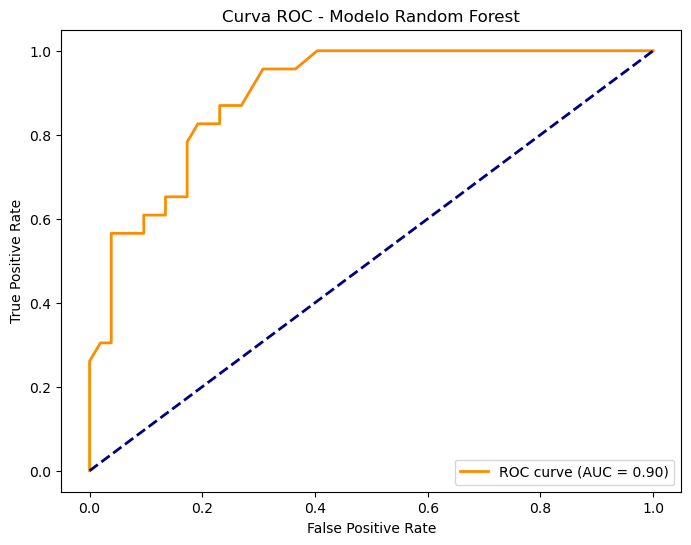

In [44]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curva ROC - Modelo Random Forest')
plt.legend(loc="lower right")
plt.grid(False)
plt.show()